# Python for Finance — Session 2 companion notebook

## 1. From syntax to reasoning with data
### 1.1 Setup and the five questions (slide "Five questions to answer before any data operation")

Run this cell first. It imports the three libraries, prints their versions (small display differences between versions are normal; Matplotlib 3.6 or later is assumed) and checks that the data file sits in the `data` folder next to this notebook. Throughout the session, ask: **shape**, **axis/labels**, **broadcast/align**, **copy/view/mutation**, **missing values**.

In [1]:
from pathlib import Path
import timeit
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("NumPy", np.__version__, "| pandas", pd.__version__, "| Matplotlib", matplotlib.__version__)

DATA_PATH = Path("data") / "session2_sales.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "data/session2_sales.csv not found: open this notebook from the folder "
        "that contains the 'data' directory."
    )
print("Data file found:", DATA_PATH.as_posix())

NumPy 1.26.4 | pandas 3.0.3 | Matplotlib 3.11.0
Data file found: data/session2_sales.csv


### 1.2 Slices and references (slide "Warm-up: slices and references")

We use a week of visitor counts rather than the slide's prices. Notice that a slice running past the end is simply shortened, while an index past the end raises an error.

In [2]:
visits = [120, 135, 128, 150, 162, 149]

print("days 2 to 4:", visits[2:5])
print("last three: ", visits[-3:])
print("reversed:   ", visits[::-1])
print("slice beyond the end:", visits[4:100])

try:
    visits[100]
except IndexError as error:
    print("Deliberate IndexError:", error)

alias = visits
independent = visits.copy()
alias[0] = 0

print("visits:     ", visits)
print("independent:", independent)
print("alias is visits:", alias is visits, "| independent == visits:", independent == visits)

days 2 to 4: [128, 150, 162]
last three:  [150, 162, 149]
reversed:    [149, 162, 150, 128, 135, 120]
slice beyond the end: [162, 149]
Deliberate IndexError: list index out of range
visits:      [0, 135, 128, 150, 162, 149]
independent: [120, 135, 128, 150, 162, 149]
alias is visits: True | independent == visits: False


## 2. NumPy
### 2.1 Operators change meaning (slide "Arrays vs. lists")

The same symbols do different things on lists and arrays. Also note that `np.append` does not grow an array: it returns a new one.

In [3]:
basket_list = [3, 4]
basket_arr = np.array([3, 4])

print("list + list:  ", basket_list + basket_list) #list
print("array + array:", basket_arr + basket_arr)   #array
print("list * 3:     ", basket_list * 3)   
print("array * 3:    ", basket_arr * 3)
print("array + list: ", basket_arr + [10, 20])   # the list is converted to an array

grown = np.append(basket_arr, 5)
print("np.append result:", grown, "| original unchanged:", basket_arr)

list + list:   [3, 4, 3, 4]
array + array: [6 8]
list * 3:      [3, 4, 3, 4, 3, 4]
array * 3:     [ 9 12]
array + list:  [13 24]
np.append result: [3 4 5] | original unchanged: [3 4]


### 2.2 Attributes and dtypes (slides "The ndarray: shape, ndim, size, dtype" and "Data types are inferred")

Our notebook array has 7 days (rows) and 4 products (coffee, tea, cake, juice). The integer dtype and the number of bytes can differ on some platforms; the shape cannot.

In [4]:
stock = np.array([[18, 12, 6, 9],
                  [21, 10, 8, 7],
                  [13, 16, 5, 11],
                  [24, 16, 9, 13],
                  [9, 11, 7, 14],
                  [27, 18, 12, 15],
                  [22, 13, 10, 6]])

print("shape:", stock.shape, "| ndim:", stock.ndim, "| size:", stock.size)
print("days (axis 0):", stock.shape[0], "| products (axis 1):", stock.shape[1])
print("len(stock):", len(stock), "(first axis only)")
print("dtype:", stock.dtype, "| bytes used:", stock.nbytes)

shape: (7, 4) | ndim: 2 | size: 28
days (axis 0): 7 | products (axis 1): 4
len(stock): 7 (first axis only)
dtype: int64 | bytes used: 224


In [5]:
for values in ([4, 5, 6], [4, 5.0, 6], [4, 5, "six"]):
    print(values, "->", np.array(values).dtype)

whole = np.array([3, 4, 5])
whole[0] = 3.99                                    # truncated, silently
print("after assigning 3.99:", whole)
print("astype(float) returns a new array:", whole.astype(float), "| still", whole.dtype)

tiny = np.array([90, 127], dtype=np.int8)          # int8 holds -128..127
print("int8 arithmetic wraps around:", tiny + tiny)

[4, 5, 6] -> int64
[4, 5.0, 6] -> float64
[4, 5, 'six'] -> <U21
after assigning 3.99: [3 4 5]
astype(float) returns a new array: [3. 4. 5.] | still int64
int8 arithmetic wraps around: [-76  -2]


### 2.3 Reshaping keeps the size (slide "Creating and reshaping arrays")

Twenty-eight values fit a 7 × 4 grid but not a 5 × something grid. `reshape` also returns a view when it can, a first hint of section 2.10.

In [6]:
flat = np.arange(28)
week_grid = flat.reshape(7, -1) # infer the second dimension
print("reshaped:", week_grid.shape)
print(np.linspace(0, 1, 5))
print(np.full((2, 4), 9.5))

try:
    flat.reshape(5, -1)
except ValueError as error:
    print("Deliberate ValueError:", error)

print("reshape shares memory with the original:", np.shares_memory(flat, week_grid))

reshaped: (7, 4)
[0.   0.25 0.5  0.75 1.  ]
[[9.5 9.5 9.5 9.5]
 [9.5 9.5 9.5 9.5]]
Deliberate ValueError: cannot reshape array of size 28 into shape (5,newaxis)
reshape shares memory with the original: True


### 2.4 Timing loop vs. vectorised expression (slide "Vectorisation to replace a loop")

A fee of 2% applies above 100, otherwise a flat fee of 1. We check that both versions agree, then time them; your numbers will differ, only the ratios matter. On five values the fixed cost of calling NumPy can dominate, and built-in `sum` on an array is far slower than `.sum()`.

In [7]:
rng = np.random.default_rng(2026)
amounts = rng.uniform(0, 200, size=1_000_000)


def fee_loop(values):
    fees = []
    for v in values:
        fees.append(v * 0.02 if v > 100 else 1.0) # A fee of 2% applies above 100, otherwise flat 1.
    return fees


def fee_vectorised(values):
    return np.where(values > 100, values * 0.02, 1.0)


print("same result:", np.allclose(fee_loop(amounts), fee_vectorised(amounts)))
loop_time = timeit.timeit(lambda: fee_loop(amounts), number=1)
vec_time = timeit.timeit(lambda: fee_vectorised(amounts), number=1)
print(f"loop: {loop_time:.3f} s | vectorised: {vec_time:.4f} s | about {loop_time / vec_time:.0f} times faster")

same result: True
loop: 0.081 s | vectorised: 0.0010 s | about 83 times faster


In [8]:
print("Vectorisation is not automatically faster for tiny arrays:")
few = np.array([3.0, 150.0, 80.0, 120.0, 40.0])
t_loop = timeit.timeit(lambda: fee_loop(few), number=20_000)
t_vec = timeit.timeit(lambda: fee_vectorised(few), number=20_000)
print(f"5 values, 20,000 repetitions -> loop: {t_loop:.3f} s | vectorised: {t_vec:.3f} s")

part = amounts[:100_000] # the first 100,000 values of the 1,000,000 array
t_builtin = timeit.timeit(lambda: sum(part), number=3)
t_method = timeit.timeit(lambda: part.sum(), number=3)
print(f"built-in sum(array): {t_builtin:.3f} s | array.sum(): {t_method:.5f} s")

Vectorisation is not automatically faster for tiny arrays:
5 values, 20,000 repetitions -> loop: 0.013 s | vectorised: 0.040 s
built-in sum(array): 0.013 s | array.sum(): 0.00028 s


### 2.5 Predicting shapes (slide "Indexing and slicing in two dimensions")

**Predict:** write down the shape of each expression before running the cell. A single integer removes an axis; a slice or a list keeps it.

In [9]:
print("shape:", stock.shape)
expressions = {
    "stock[6, 3]": stock[6, 3],
    "stock[-1]": stock[-1],
    "stock[:, 1]": stock[:, 1],
    "stock[:, [1]]": stock[:, [1]],
    "stock[::2, 1:]": stock[::2, 1:],
}
for text, result in expressions.items():
    print(f"{text:15} -> shape {np.shape(result)}")

print(stock[::2, 1:])

shape: (7, 4)
stock[6, 3]     -> shape ()
stock[-1]       -> shape (4,)
stock[:, 1]     -> shape (7,)
stock[:, [1]]   -> shape (7, 1)
stock[::2, 1:]  -> shape (4, 3)
[[12  6  9]
 [16  5 11]
 [11  7 14]
 [13 10  6]]


### 2.6 Masks, replacement and np.where (slides "Boolean masks" and "Selecting and replacing with masks")

Masks count, filter and replace. We also trigger the two classic mistakes (using `and`, forgetting parentheses) and show that `np.where` computes both branches.

In [10]:
busy = stock >= 15
print("busy days per product:", busy.sum(axis=0))
print("share of busy cells:", round(float(busy.mean()), 3))

moderate = (stock >= 10) & ~(stock > 20)
print("cells between 10 and 20:", moderate.sum())

try:
    (stock >= 10) and (stock <= 20) #single value error
except ValueError as error:
    print("Deliberate ValueError:", error)

try:
    stock >= 10 & stock <= 20      # & is evaluated before >= and <=
except ValueError as error:
    print("Deliberate ValueError (missing parentheses):", error)

busy days per product: [5 3 0 1]
share of busy cells: 0.321
cells between 10 and 20: 15
Deliberate ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()
Deliberate ValueError (missing parentheses): The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()


In [11]:
capped = stock.copy()
capped[capped > 20] = 20
print("max after capping:", capped.max(), "| original max:", stock.max())
print(np.where(stock[0] > 10, "restock", "ok"))

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    x = np.array([0.0, 2.0, 4.0])
    inverse = np.where(x > 0, 1 / x, 0.0)
print("inverse:", inverse)
print("warnings raised anyway:", [w.category.__name__ for w in caught])

max after capping: 20 | original max: 27
['restock' 'restock' 'ok' 'ok']
inverse: [0.   0.5  0.25]
warnings raised anyway: []


**HW 1.** For each product, compute the fraction of days on which at least 15 units were sold. \
The result should have shape `(4,)`.\
Mind that: coffee reaches 15 on five of the seven days, so its value is about 0.714.

In [12]:
fraction_busy = None   # replace None with your expression

if fraction_busy is None:
    print("Not attempted yet.")
else:
    print("shape:", np.shape(fraction_busy), "| expected: (4,)")
    print("values:", np.round(fraction_busy, 3), "| coffee should be 0.714")

Not attempted yet.


### 2.7 Which axis disappears? (slide "Reductions and the axis argument")

With shape `(7, 4)`, `axis=0` removes the 7 days and `axis=1` removes the 4 products. The index returned by `argmax` can select names from another array.

In [13]:
product_names = np.array(["coffee", "tea", "cake", "juice"])

print("total per product (axis=0):", stock.sum(axis=0))
print("total per day (axis=1):    ", stock.sum(axis=1))
print("overall mean:", round(float(stock.mean()), 2))

best = stock.argmax(axis=1)
print("best product index per day:", best)
print("best product name per day: ", product_names[best])

total per product (axis=0): [134  96  57  75]
total per day (axis=1):     [45 46 45 62 41 72 51]
overall mean: 12.93
best product index per day: [0 0 1 0 3 0 0]
best product name per day:  ['coffee' 'coffee' 'tea' 'coffee' 'juice' 'coffee' 'coffee']


### 2.8 Broadcasting by shape (slide "Broadcasting: the shape rule")

Prices have shape `(4,)` and match the last axis. Daily totals have shape `(7,)` and do not. A `(7, 1)` column of daily factors broadcasts against `(4,)` into a full `(7, 4)` table.

In [14]:
price = np.array([2.5, 2.0, 3.5, 3.0])
revenue = stock * price                               # (7, 4) * (4,)
print("revenue shape:", revenue.shape)

daily_total = stock.sum(axis=1)                       # (7,)
try:
    stock - daily_total
except ValueError as error:
    print("Deliberate ValueError:", error)

promo = np.array([1.0, 1.0, 0.9, 1.0, 1.0, 0.8, 0.8])[:, None]   # (7, 1)
print("(7, 1) * (4,) ->", (promo * price).shape)
print((promo * price)[-2:])

revenue shape: (7, 4)
Deliberate ValueError: operands could not be broadcast together with shapes (7,4) (7,) 
(7, 1) * (4,) -> (7, 4)
[[2.  1.6 2.8 2.4]
 [2.  1.6 2.8 2.4]]


### 2.9 Shape assertions (slide "Broadcasting: keepdims and silent mistakes")

Row shares need `keepdims=True`; column shares do not, because the collapsed axis is the first one and the result lines up with the last axis. The last example multiplies a column by a row without noticing, and an `assert` catches it.

In [15]:
day_share = stock / stock.sum(axis=1, keepdims=True)
product_share = stock / stock.sum(axis=0)             # (7, 4) / (4,)
assert day_share.shape == stock.shape
print("rows sum to 1:", np.allclose(day_share.sum(axis=1), 1))
print("columns sum to 1:", np.allclose(product_share.sum(axis=0), 1))

weights = np.array([0.5, 0.3, 0.2])                   # (3,)
first_days = stock[:3, :1]                            # (3, 1): a column, by mistake
weighted = first_days * weights
try:
    assert weighted.shape == (3, 1), f"expected (3, 1), got {weighted.shape}"
except AssertionError as error:
    print("Deliberate AssertionError:", error)

rows sum to 1: True
columns sum to 1: True
Deliberate AssertionError: expected (3, 1), got (3, 3)


**HW 2.** Subtract each product's mean (the mean of its column) from that column. \
The result keeps shape `(7, 4)` and its column means are all close to 0.

In [16]:
centred = None   # replace None with your expression

if centred is None:
    print("Not attempted yet.")
else:
    print("shape:", np.shape(centred), "| expected: (7, 4)")
    print("column means close to 0:", np.allclose(np.mean(centred, axis=0), 0))

Not attempted yet.


### 2.10 View or copy? (slide "Views and copies")

**Predict:** after changing a slice and a masked selection, what does `queue` contain? Then we check memory sharing for several operations.

In [17]:
queue = np.array([4, 9, 2, 7, 5, 8])

head = queue[:2]                  # slice
head[:] = -1
long_waits = queue[queue > 6]     # mask
long_waits[:] = 0

print("queue after both changes:", queue)

queue after both changes: [-1 -1  2  7  5  8]


In [18]:
grid = np.arange(12).reshape(3, 4)
candidates = {
    "grid[1:, :2]    (slice)": grid[1:, :2],
    "grid.T          (transpose)": grid.T,
    "grid.reshape(4, 3)": grid.reshape(4, 3),
    "grid[grid > 5]  (mask)": grid[grid > 5],
    "grid[[0, 2]]    (list)": grid[[0, 2]],
    "grid.copy()": grid.copy(),
}
for name, result in candidates.items():
    print(f"{name:28} shares memory: {np.shares_memory(grid, result)}")

grid[grid > 9] = 0                # changing the original on purpose, in one assignment
print(grid)

grid[1:, :2]    (slice)      shares memory: True
grid.T          (transpose)  shares memory: True
grid.reshape(4, 3)           shares memory: True
grid[grid > 5]  (mask)       shares memory: False
grid[[0, 2]]    (list)       shares memory: False
grid.copy()                  shares memory: False
[[0 1 2 3]
 [4 5 6 7]
 [8 9 0 0]]


### 2.11 NaN and inf (slide "Missing and non-finite values")

`np.nanmean` ignores `nan` but not `inf`; `np.isfinite` removes both. Integer arrays cannot store `nan` at all.

In [19]:
readings = np.array([19.5, np.nan, 21.0, np.inf, 20.5])

print("mean:", readings.mean(), "| nanmean:", np.nanmean(readings))
finite = readings[np.isfinite(readings)]
print("finite readings:", finite, "| their mean:", round(float(finite.mean()), 2))

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    ratios = np.array([1.0, 0.0]) / np.array([0.0, 0.0])
print("ratios:", ratios, "| warnings:", [w.category.__name__ for w in caught])

counts = np.array([3, 4, 5])
try:
    counts[0] = np.nan
except ValueError as error:
    print("Deliberate ValueError:", error)

mean: nan | nanmean: inf
finite readings: [19.5 21.  20.5] | their mean: 20.33
ratios: [inf nan] | warnings: []
Deliberate ValueError: cannot convert float NaN to integer


### 2.12 Seeds and generators (check slide "Reproducible random numbers")

Two generators with the same seed produce the same draws. Passing the generator into a function keeps a simulation reproducible without any global state.

In [20]:
rolls_a = np.random.default_rng(123).integers(1, 7, size=12)
rolls_b = np.random.default_rng(123).integers(1, 7, size=12)
rolls_c = np.random.default_rng(124).integers(1, 7, size=12)
print(rolls_a)
print("same seed, same draws:     ", np.array_equal(rolls_a, rolls_b))
print("different seed, same draws:", np.array_equal(rolls_a, rolls_c))
print("7 drawn in 10,000 rolls?", 7 in np.random.default_rng(1).integers(1, 7, size=10_000)) # 7 is excluded


def simulate_orders(generator, n_days):
    return generator.choice(["coffee", "tea", "cake"], size=n_days)


print(simulate_orders(np.random.default_rng(5), 6))

[1 5 4 1 6 2 2 2 3 2 3 5]
same seed, same draws:      True
different seed, same draws: False
7 drawn in 10,000 rolls? False
['cake' 'cake' 'coffee' 'cake' 'tea' 'tea']


### 2.13 Elementwise or matrix product? (slide "Elementwise versus matrix multiplication")

`stock * price` keeps one revenue per cell; `stock @ price` gives one revenue per day. For `@`, the inner sizes must agree.

In [21]:
print("stock * price:", (stock * price).shape)
print("stock @ price:", (stock @ price).shape, stock @ price)
print("1-D @ 1-D is a single number:", np.array([1, 2, 3]) @ np.array([4, 5, 6]))

left = np.ones((4, 2))
try:
    left @ np.ones((3, 5))
except ValueError as error:
    print("Deliberate ValueError:", error)
print("(4, 2) @ (2, 5) ->", (left @ np.ones((2, 5))).shape)

stock * price: (7, 4)
stock @ price: (7,) [117.  121.5 115.  162.5 111.  190.5 134. ]
1-D @ 1-D is a single number: 32
Deliberate ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 2)
(4, 2) @ (2, 5) -> (4, 5)


### 2.14 Recovering prices (slide "Solving a linear system")

Four days and four products give four equations for four unknown prices. When one day is the sum of two others, the system has no unique solution. **Predict:** does `solve` raise an error? In floating point it may not: it can silently return huge numbers, so the residual check `np.allclose(A @ x, b)` is what tells us.

In [22]:
A = stock[:4].astype(float)       # units on days 0-3
b = A @ price                     # the four daily revenues
recovered = np.linalg.solve(A, b)
print("recovered prices:", recovered.round(2))
print("A @ p matches b:", np.allclose(A @ recovered, b))

singular = A.copy()
singular[3] = singular[0] + singular[1]      # day 3 = day 0 + day 1
try:
    x = np.linalg.solve(singular, b)
except np.linalg.LinAlgError as error:
    print("LinAlgError raised:", error)
else:
    print("no error raised; largest |x|:", f"{np.abs(x).max():.1e}")
    print("residual check passes:", np.allclose(singular @ x, b))
print("rank of the matrix:", np.linalg.matrix_rank(singular), "(4 would be needed)")

recovered prices: [2.5 2.  3.5 3. ]
A @ p matches b: True
no error raised; largest |x|: 2.4e+17
residual check passes: False
rank of the matrix: 3 (4 would be needed)


### 2.15 NumPy In-class checkpoint (slides "Reductions and the axis argument", "Broadcasting: the shape rule", "Views and copies" and "Missing and non-finite values")

**Predict** the four answers first: (1) the shape of `stock.max(axis=0)`; (2) whether `stock + np.ones(7)` broadcasts; (3) whether changing a column slice changes the array; (4) `np.nanmax([2.0, np.nan, 5.0])`.

In [23]:
print("1)", stock.max(axis=0).shape)

try:
    stock + np.ones(7)
    print("2) it broadcasts")
except ValueError:
    print("2) it does not broadcast: (7, 4) against (7,)")

checkpoint = stock.copy()
first_column = checkpoint[:, 0]
first_column[0] = 0
print("3) the array changed:", checkpoint[0, 0] == 0)
print("4)", np.nanmax([2.0, np.nan, 5.0]))

1) (4,)
2) it does not broadcast: (7, 4) against (7,)
3) the array changed: True
4) 5.0


## 3. Matplotlib
### 3.1 One figure, one Axes (slide "Figure and Axes")

We simulate 21 days of visitors for four shops. The second cell shows why `plt.title` is ambiguous: it silently targets the last Axes created.

Figure Axes | Axes in this figure: 1


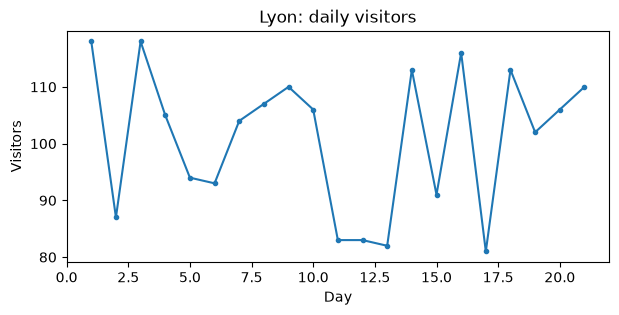

In [24]:
rng = np.random.default_rng(99)
footfall = rng.integers(80, 120, size=(21, 4))       # 21 days x 4 shops
shop_labels = ["Lyon", "Paris A", "Paris B", "Lille"]
day_numbers = np.arange(1, 22)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(day_numbers, footfall[:, 0], marker=".")
ax.set(xlabel="Day", ylabel="Visitors", title="Lyon: daily visitors")
print(type(fig).__name__, type(ax).__name__, "| Axes in this figure:", len(fig.axes))
plt.show()

left title: '' | right title: 'Which panel gets this title?'


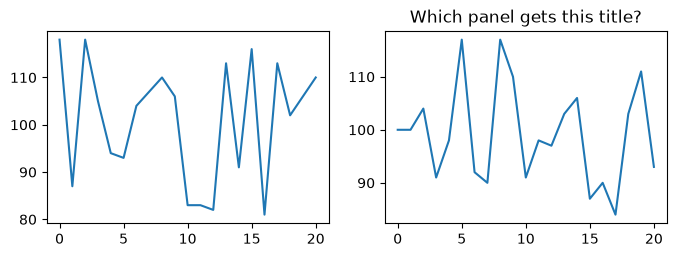

In [25]:
fig, (left_ax, right_ax) = plt.subplots(1, 2, figsize=(8, 2.5))
left_ax.plot(footfall[:, 0])
right_ax.plot(footfall[:, 1])
plt.title("Which panel gets this title?")         # pyplot acts on the "current" Axes
print("left title:", repr(left_ax.get_title()), "| right title:", repr(right_ax.get_title()))
plt.show()

### 3.2 Four shops, four labelled lines (slide "Plotting several series")

Markers as well as colours keep the lines distinguishable in print. Passing a 2-D array to `plot` draws one line per column.

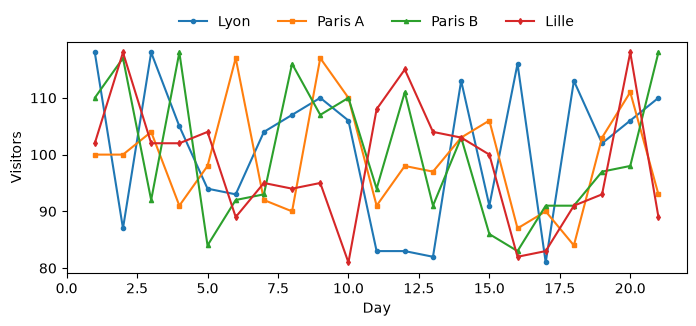

lines drawn: 4 | columns in footfall: 4


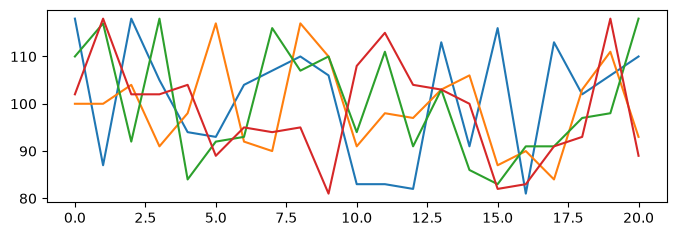

In [26]:
fig, ax = plt.subplots(figsize=(8, 3))
for j, name in enumerate(shop_labels):
    ax.plot(day_numbers, footfall[:, j], label=name, marker="os^d"[j], markersize=3)
ax.set(xlabel="Day", ylabel="Visitors")
ax.legend(ncols=4, loc="lower center", bbox_to_anchor=(0.5, 1.0), frameon=False)
plt.show()

fig, ax = plt.subplots(figsize=(8, 2.5))
lines = ax.plot(footfall)
print("lines drawn:", len(lines), "| columns in footfall:", footfall.shape[1])
plt.show()

### 3.3 Histograms depend on bins (slide "Choosing a chart for the question")

 A histogram answers "how is it distributed?", but the answer depends on the number of bins. Compare 5 and 25 bins on the same values.

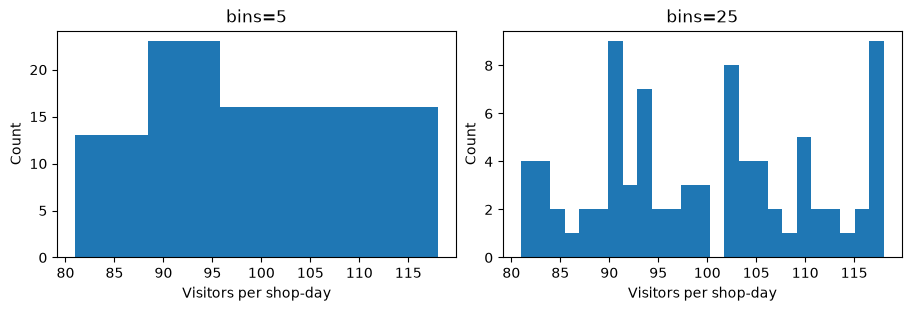

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3), layout="constrained")
for ax, bins in zip(axes, [5, 25]):
    ax.hist(footfall.ravel(), bins=bins)
    ax.set(title=f"bins={bins}", xlabel="Visitors per shop-day", ylabel="Count")
plt.show()

### 3.4 Zeros that are not visitors (slide "A chart that reveals a problem")

To update data: we receive records three closed days as 0 visitors for Paris B. **Predict:** would the means or the minimums reveal it? Then plot, and redraw with the zeros treated as missing: Matplotlib leaves a gap at `nan`.

In [28]:
received = footfall.copy()
received[11:14, 2] = 0                      # three closed days recorded as 0
print("mean visitors per shop:", received.mean(axis=0).round(1))
print("minimum per shop:      ", received.min(axis=0))

mean visitors per shop: [101.   99.1  85.6  98.5]
minimum per shop:       [81 84  0 81]


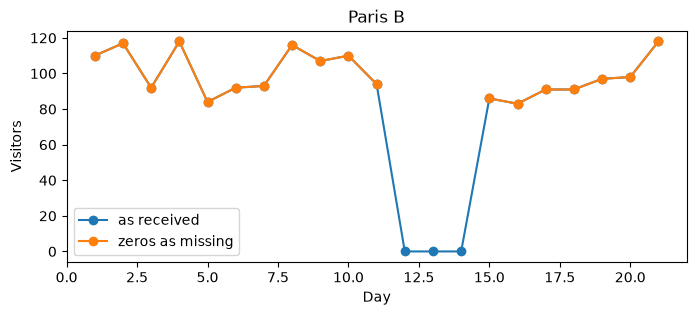

mean with zeros: 85.6 | mean without closed days: 99.8


In [29]:
cleaned = received[:, 2].astype(float)      # a float copy can hold nan
cleaned[cleaned == 0] = np.nan

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(day_numbers, received[:, 2], marker="o", label="as received")
ax.plot(day_numbers, cleaned, marker="o", label="zeros as missing")
ax.set(xlabel="Day", ylabel="Visitors", title="Paris B")
ax.legend()
plt.show()

print("mean with zeros:", round(float(received[:, 2].mean()), 1),
      "| mean without closed days:", round(float(np.nanmean(cleaned)), 1))

### 3.5 Two panels, a highlight and a saved file (slide "Several panels in one figure")

The left panel highlights the closed days; the right panel sorts the bars. The figure is saved to an `outputs` folder created next to the notebook.

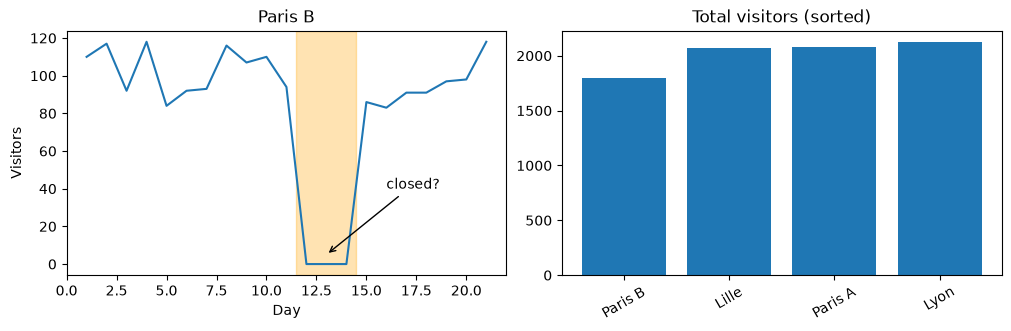

In [30]:
totals = received.sum(axis=0)
order = np.argsort(totals)                           # smallest first

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), layout="constrained")
axes[0].plot(day_numbers, received[:, 2])
axes[0].axvspan(11.5, 14.5, color="orange", alpha=0.3)
axes[0].annotate("closed?", xy=(13, 5), xytext=(16, 40), arrowprops={"arrowstyle": "->"})
axes[0].set(xlabel="Day", ylabel="Visitors", title="Paris B")
axes[1].bar(np.array(shop_labels)[order], totals[order])
axes[1].tick_params(axis="x", labelrotation=30)
axes[1].set(title="Total visitors (sorted)")

Path("outputs").mkdir(exist_ok=True)
fig.savefig(Path("outputs") / "visitors.png", dpi=120)
plt.show()

**HW 3**. Fill in a 1 × 2 figure: on the left a histogram of all values in `received`; on the right a bar chart of the mean visitors per shop, with a dashed horizontal line at the overall mean.

elements drawn per panel: [0, 0] | both numbers should be above 0


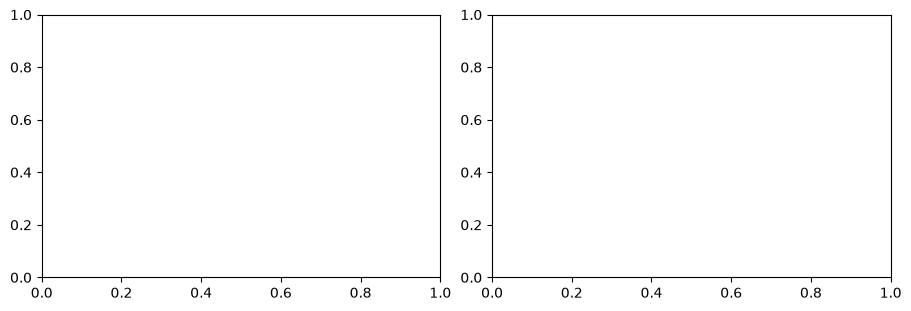

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3), layout="constrained")

# ... your plotting code here ...

drawn = [len(ax.patches) + len(ax.lines) for ax in axes]
print("elements drawn per panel:", drawn, "| both numbers should be above 0")
plt.show()

## 4. Pandas
### 4.1 Tables built from Python objects (slide "Series and DataFrame")

The two lookup tables of this section are created in Python, not loaded from disk. A Series can carry meaningful labels instead of 0, 1, 2. Converting a mixed table to NumPy produces a generic `object` array.

In [32]:
products = pd.DataFrame({"product": ["coffee", "tea", "cake"],
                         "unit_price": [2.5, 2.0, 3.5]})
shops = pd.DataFrame({"shop_id": ["001", "002", "003", "004"],
                      "city": ["Lyon", "Paris", "Paris", "Lille"],
                      "region": ["South", "North", "North", "North"]})
print(shops)
print("index:", list(shops.index), "| columns:", list(shops.columns))

price_by_name = pd.Series([2.5, 2.0, 3.5], index=["coffee", "tea", "cake"], name="unit_price")
print(price_by_name)
print("to_numpy() on the mixed shops table:", shops.to_numpy().dtype)

  shop_id   city region
0     001   Lyon  South
1     002  Paris  North
2     003  Paris  North
3     004  Lille  North
index: [0, 1, 2, 3] | columns: ['shop_id', 'city', 'region']
coffee    2.5
tea       2.0
cake      3.5
Name: unit_price, dtype: float64
to_numpy() on the mixed shops table: object


### 4.2 A first look at the file (slide "Loading and inspecting a local file")

We load the CSV without any options, exactly as a first attempt would. Text columns display as `object` in pandas 2 and `str` in pandas 3.

In [33]:
raw = pd.read_csv(DATA_PATH)
print("rows, columns:", raw.shape)
print(raw.head())
raw.info()
print(raw.nunique())

rows, columns: (490, 4)
         date  shop_id product units
0  2026-03-02        1  coffee    37
1  2026-03-02        1     tea    15
2  2026-03-02        1    cake     9
3  2026-03-02        2  coffee    44
4  2026-03-02        2     tea    20
<class 'pandas.DataFrame'>
RangeIndex: 490 entries, 0 to 489
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   date     490 non-null    str  
 1   shop_id  490 non-null    int64
 2   product  490 non-null    str  
 3   units    490 non-null    str  
dtypes: int64(1), str(3)
memory usage: 23.2 KB
date       42
shop_id     4
product     3
units      67
dtype: int64


### 4.3 Finding and repairing bad types (slide "When numbers are read as text")

**Predict:** what is the "largest" value of a text column containing digits and the word `missing`? We then locate the offending rows and reload the file properly. `describe()` now exposes a suspicious maximum. Note two text dtypes: `string` is the one we requested for `shop_id`; `product` keeps pandas' default text type (`str` in pandas 3, `object` in pandas 2).

In [34]:
print("largest value of the text column:", raw["units"].max())

not_digits = ~raw["units"].str.isnumeric()
print(raw.loc[not_digits])
print("values that to_numeric cannot convert:", pd.to_numeric(raw["units"], errors="coerce").isna().sum())

largest value of the text column: missing
           date  shop_id product    units
28   2026-03-04        2     tea  missing
54   2026-03-06        3  coffee  missing
103  2026-03-10        3     tea  missing
145  2026-03-14        1     tea  missing
169  2026-03-16        1    cake  missing
176  2026-03-16        5  coffee  missing
464  2026-04-10        5  coffee  missing
485  2026-04-12        3     tea  missing
values that to_numeric cannot convert: 8


In [35]:
sales = pd.read_csv(DATA_PATH,
                    na_values=["missing"],  # we import the string "missing" as a NaN
                    dtype={"shop_id": "string"},
                    parse_dates=["date"])
print(sales.dtypes)
sales["units"].describe()

date       datetime64[us]
shop_id            string
product               str
units             float64
dtype: object


count    482.000000
mean      24.840249
std       29.576523
min        3.000000
25%       12.000000
50%       19.000000
75%       32.000000
max      580.000000
Name: units, dtype: float64

### 4.4 Series or DataFrame? (slide "Selecting columns")

Single versus double brackets change the type and the shape. A misspelt column raises `KeyError`, and a column named `count` cannot be reached with a dot.

In [36]:
product_col = sales["product"]
two_cols = sales[["date", "product"]]
print(type(product_col).__name__, product_col.shape, "|", type(two_cols).__name__, two_cols.shape)

try:
    sales["unit"]
except KeyError as error:
    print("Deliberate KeyError:", error)

tally = pd.DataFrame({"count": [4, 1], "product": ["tea", "cake"]})
print("tally.count is a method:", callable(tally.count), "| tally['count']:", tally["count"].tolist())

Series (490,) | DataFrame (490, 2)
Deliberate KeyError: 'unit'
tally.count is a method: True | tally['count']: [4, 1]


### 4.5 Labels versus positions (slide "loc vs. iloc")

**Predict** how many rows each selection returns. With shop IDs as the index, the label slice `"002":"004"` includes its end, the positional slice `1:3` does not.

In [37]:
by_id = shops.set_index("shop_id")
print(by_id.loc["002":"004"])
print(by_id.iloc[1:3])
print("")
print(by_id.loc[["001", "004"], "city"].tolist())

try:
    by_id.loc[["001", "005"]]
except KeyError as error:
    print("Deliberate KeyError:", error)

          city region
shop_id              
002      Paris  North
003      Paris  North
004      Lille  North
          city region
shop_id              
002      Paris  North
003      Paris  North

['Lyon', 'Lille']
Deliberate KeyError: "['005'] not in index"


### 4.6 Sorting keeps labels (slide "Labels travel with their rows")

`sales.loc[:5]` is a label slice, so it returns six rows. After sorting, label 0 and position 0 point to different rows until we reset the index.

In [38]:
extract = sales.loc[:5, ["shop_id", "product", "units"]]
ranked = extract.sort_values("units")
print(ranked)
print("loc[0]:", ranked.loc[0, "units"], "| iloc[0]:", ranked["units"].iloc[0])
print(ranked.reset_index(drop=True).head(2))

  shop_id product  units
2     001    cake    9.0
1     001     tea   15.0
5     002    cake   16.0
4     002     tea   20.0
0     001  coffee   37.0
3     002  coffee   44.0
loc[0]: 37.0 | iloc[0]: 9.0
  shop_id product  units
0     001    cake    9.0
1     001     tea   15.0


### 4.7 Three conditions at once (slide "Filtering rows")

Each condition sits in its own parentheses. `~isin` finds the shop that the lookup table does not know.

In [39]:
tea_rows = sales.loc[(sales["product"] == "tea")
                     & (sales["shop_id"].isin(["001", "003"]))
                     & (sales["units"] > 25),
                     ["date", "shop_id", "units"]]
print("matching rows:", len(tea_rows))
print(tea_rows.head())

unknown = sales.loc[~sales["shop_id"].isin(shops["shop_id"]), "shop_id"].unique()
print("shops missing from the lookup table:", list(unknown))

matching rows: 16
          date shop_id  units
49  2026-03-06     001   28.0
61  2026-03-07     001   26.0
73  2026-03-08     001   28.0
79  2026-03-08     003   26.0
121 2026-03-12     001   27.0
shops missing from the lookup table: ['005']


**HW 4.** How many rows in the last seven days of the data (the latest date and the six days before it) have a missing `units` value? Hint: `sales["date"].max()` and `pd.Timedelta(days=6)`.

In [40]:
n_missing_last_week = None   # replace None with your expression

if n_missing_last_week is None:
    print("Not attempted yet.")
else:
    print("your answer:", n_missing_last_week, "| target: 2")

Not attempted yet.


### 4.8 Deriving columns from dates and conditions ( "Creating columns without loops")

`assign` returns a new table with three new columns; `sales` is untouched. The timing compares a row-by-row `apply` with the vectorised expression on a 20-times larger table.

In [41]:
enriched = sales.assign(
    weekday=sales["date"].dt.day_name(),
    is_weekend=sales["date"].dt.dayofweek >= 5,
    volume=np.where(sales["units"] >= 30, "high", "normal"),
)
print(enriched.head())
print("columns of sales:", list(sales.columns)) #to double-check that the original DataFrame is unchanged.

        date shop_id product  units weekday  is_weekend  volume
0 2026-03-02     001  coffee   37.0  Monday       False    high
1 2026-03-02     001     tea   15.0  Monday       False  normal
2 2026-03-02     001    cake    9.0  Monday       False  normal
3 2026-03-02     002  coffee   44.0  Monday       False    high
4 2026-03-02     002     tea   20.0  Monday       False  normal
columns of sales: ['date', 'shop_id', 'product', 'units']


In [42]:
bigger = pd.concat([sales] * 20, ignore_index=True)
t_apply = timeit.timeit(lambda: bigger.apply(lambda row: row["units"] * 2, axis=1), number=1)
t_vector = timeit.timeit(lambda: bigger["units"] * 2, number=1)
print(f"{len(bigger)} rows -> apply(axis=1): {t_apply:.3f} s | vectorised: {t_vector:.5f} s")

9800 rows -> apply(axis=1): 0.024 s | vectorised: 0.00014 s


### 4.9 Marking a suspicious value as missing (slide "Changing values safely")

One row holds 580 units, about ten times its shop's usual coffee sales. Here we mark it as missing with one `.loc` assignment on `sales` itself. (The challenge in section 5 asks for a different repair.) A `.copy()` gives an independent subset.

In [43]:
suspicious = sales["units"] > 300
print(sales.loc[suspicious, ["date", "shop_id", "product", "units"]])
print("")
sales.loc[suspicious, "units"] = np.nan          # one assignment: modifies sales
print("largest units now:", sales["units"].max(), "| missing now:", sales["units"].isna().sum())
print("")
is_weekend = sales["date"].dt.dayofweek >= 5
weekend_rows = sales.loc[is_weekend].copy()          # an independent subset
weekend_rows["units"] = 0
print("weekend units in sales, still:", sales.loc[is_weekend, "units"].sum())
print("")
result = weekend_rows.sort_values("units", inplace=True) # sorts the DataFrame in place and returns None
print("inplace=True returned:", result)

          date shop_id product  units
194 2026-03-18     002  coffee  580.0

largest units now: 78.0 | missing now: 9

weekend units in sales, still: 3997.0

inplace=True returned: None


### 4.10 Labels decide the match (slide "Index alignment")

**Predict:** which shops get `NaN` when visits are divided by opening hours? The two Series list different shops, in a different order. Then assign a shuffled, partial Series (matched by label, NaN where absent) and an array (taken by position).

In [44]:
opening_hours = pd.Series({"001": 60, "002": 72, "003": 60, "004": 48}) #missing 005
visits_week = pd.Series({"005": 410, "003": 380, "002": 655, "001": 520}) #missing 004

print((visits_week / opening_hours).round(2)) # missing shops are treated as NaN.
extra = pd.Series({"001": 30, "004": 12})
print("")
print(visits_week.add(extra, fill_value=0)) 

late_hours = pd.Series({"004": 22, "001": 20})              # shuffled, and only two shops
board = shops.set_index("shop_id")
board["closes_at"] = late_hours                              # a Series: aligned by label
board["by_position"] = np.array([22, 20, 21, 19])            # an array: taken by position
print(board)

001    8.67
002    9.10
003    6.33
004     NaN
005     NaN
dtype: float64

001    550.0
002    655.0
003    380.0
004     12.0
005    410.0
dtype: float64
          city region  closes_at  by_position
shop_id                                      
001       Lyon  South       20.0           22
002      Paris  North        NaN           20
003      Paris  North        NaN           21
004      Lille  North       22.0           19


### 4.11 Missing units, counted several ways (slide "Missing values in tables")

Nine values are now missing: the eight `missing` tokens and the value marked in 4.9. Pandas and NumPy disagree on the mean unless we tell NumPy to ignore `nan`.

In [45]:
print("missing units:", sales["units"].isna().sum(), "of", len(sales), "rows")
print("")
print(sales.loc[sales["units"].isna(), ["date", "shop_id", "product"]])
print("")
print("pandas mean (skips NaN):", round(sales["units"].mean(), 2))
print("NumPy mean on the same values:", sales["units"].to_numpy().mean())
print("np.nanmean:", round(float(np.nanmean(sales["units"].to_numpy())), 2))
print("")
print("rows kept by dropna:", len(sales.dropna(subset=["units"])))
print("mean after fillna(0):", round(sales["units"].fillna(0).mean(), 2)) # missing values as 0 might influence.

missing units: 9 of 490 rows

          date shop_id product
28  2026-03-04     002     tea
54  2026-03-06     003  coffee
103 2026-03-10     003     tea
145 2026-03-14     001     tea
169 2026-03-16     001    cake
176 2026-03-16     005  coffee
194 2026-03-18     002  coffee
464 2026-04-10     005  coffee
485 2026-04-12     003     tea

pandas mean (skips NaN): 23.69
NumPy mean on the same values: nan
np.nanmean: 23.69

rows kept by dropna: 481
mean after fillna(0): 23.25


### 4.12 Grouping by one/two keys (slide "Split, apply, combine")

One key gives one row per product. Two keys give a two-level index; `unstack` moves the second key into the columns. The last lines show two silent defaults: a row whose key is missing is dropped, and a group with only missing values sums to 0.

In [46]:
units_per_product = sales.groupby("product")["units"].sum()
print(units_per_product)
print("index of the result:", list(units_per_product.index))
print("")
two_keys = sales.groupby(["shop_id", "product"])["units"].sum()
print(two_keys.head(4))
print("")
print(two_keys.unstack())
print("")
tiny = pd.DataFrame({"shop_id": ["001", "002", None], "units": [np.nan, 4.0, 7.0]})
print("default:        ", tiny.groupby("shop_id")["units"].sum().to_dict())
print("dropna=False and min_count=1:", tiny.groupby("shop_id", dropna=False)["units"].sum(min_count=1).to_dict())

product
cake      1948.0
coffee    6349.0
tea       3096.0
Name: units, dtype: float64
index of the result: ['cake', 'coffee', 'tea']

shop_id  product
001      cake        527.0
         coffee     1808.0
         tea         896.0
002      cake        702.0
Name: units, dtype: float64

product   cake  coffee     tea
shop_id                       
001      527.0  1808.0   896.0
002      702.0  2278.0  1052.0
003      394.0  1288.0   613.0
005      325.0   975.0   535.0

default:         {'001': 0.0, '002': 4.0}
dropna=False and min_count=1: {'001': nan, '002': 4.0, nan: 7.0}


### 4.13 A per-shop summary (slide "Named aggregation")

`size` counts rows and `count` counts recorded values, so their difference is the number of missing units per shop.

In [47]:
per_shop = (sales.groupby("shop_id")
                 .agg(total_units=("units", "sum"),
                      rows=("units", "size"),
                      recorded=("units", "count"),
                      first_day=("date", "min"),
                      last_day=("date", "max"))
                 .reset_index()
                 .sort_values("total_units", ascending=False))
per_shop

,shop_id,total_units,rows,recorded,first_day,last_day
1,002,4032.0,125,123,2026-03-02,2026-04-12
0,001,3231.0,125,123,2026-03-02,2026-04-12
2,003,2295.0,115,112,2026-03-02,2026-04-12
3,005,1835.0,125,123,2026-03-02,2026-04-12


### 4.14 One value per row (slide "To aggregate or to transform?")

**Predict** the shape of the `transform` result. We use it for each row's share of its product's total, and to centre units within each shop-product group.

In [48]:
product_total = sales.groupby("product")["units"].transform("sum")
print("sales:", sales.shape, "| transform result:", product_total.shape)
print("")
with_share = sales.assign(share_of_product=sales["units"] / product_total)
print(with_share.head(3))
print("")
print("shares sum to 1 within each product:",
      np.allclose(with_share.groupby("product")["share_of_product"].sum(), 1))

deviation = sales["units"] - sales.groupby(["shop_id", "product"])["units"].transform("mean")
print("within-group deviations average to 0:", abs(deviation.mean()) < 1e-9)

sales: (490, 4) | transform result: (490,)

        date shop_id product  units  share_of_product
0 2026-03-02     001  coffee   37.0          0.005828
1 2026-03-02     001     tea   15.0          0.004845
2 2026-03-02     001    cake    9.0          0.004620

shares sum to 1 within each product: True
within-group deviations average to 0: True


### 4.15 Adding prices to every row (slide "Merging a table")

The price table has exactly one row per product, so a validated many-to-one merge keeps all 490 rows.

In [49]:
with_prices = sales.merge(products, on="product", how="left", validate="many_to_one")
print("rows before:", len(sales), "| rows after:", len(with_prices))

with_prices["revenue"] = with_prices["units"] * with_prices["unit_price"]
print(with_prices.head(3))
print(with_prices.groupby("product")["revenue"].sum().round(2))

rows before: 490 | rows after: 490
        date shop_id product  units  unit_price  revenue
0 2026-03-02     001  coffee   37.0         2.5     92.5
1 2026-03-02     001     tea   15.0         2.0     30.0
2 2026-03-02     001    cake    9.0         3.5     31.5
product
cake       6818.0
coffee    15872.5
tea        6192.0
Name: revenue, dtype: float64


### 4.16 Row counts, duplicates and key types (slide "Auditing a merge")

The four `how` options give four row counts. Shop 005 has no partner in the lookup table, and shop 004 has no sales. A duplicated key multiplies rows; IDs stored as numbers cannot match IDs stored as text until they are repaired.

In [50]:
for how in ["left", "inner", "right", "outer"]: # the four merge types: left is the default, inner is the intersection, right is the opposite of left, outer is the union.
    merged = sales.merge(shops, on="shop_id", how=how, indicator=True)
    print(f"{how:5} rows: {len(merged):3} |", merged["_merge"].value_counts(sort=False).to_dict())

left  rows: 490 | {'left_only': 125, 'right_only': 0, 'both': 365}
inner rows: 365 | {'left_only': 0, 'right_only': 0, 'both': 365}
right rows: 366 | {'left_only': 0, 'right_only': 1, 'both': 365}
outer rows: 491 | {'left_only': 125, 'right_only': 1, 'both': 365}


In [51]:
price_list_v2 = pd.DataFrame({"product": ["coffee", "tea", "cake", "tea"],
                              "unit_price": [2.5, 2.0, 3.5, 2.2]})     # tea listed twice
print("rows after merging on a duplicated key:", len(sales.merge(price_list_v2, on="product")))
try:
    sales.merge(price_list_v2, on="product", validate="many_to_one")
except pd.errors.MergeError as error:
    print("Deliberate MergeError:", str(error).splitlines()[0])

shops_numeric = shops.assign(shop_id=[1, 2, 3, 4])       # IDs that lost their zeros
try:
    sales.merge(shops_numeric, on="shop_id")
except ValueError as error:
    print("Deliberate ValueError:", error)

repaired = shops_numeric.assign(shop_id=shops_numeric["shop_id"].astype(str).str.zfill(3))
print("rows matched after zfill:", len(sales.merge(repaired, on="shop_id")))

rows after merging on a duplicated key: 653
Deliberate MergeError: Merge keys are not unique in right dataset; not a many-to-one merge
Deliberate ValueError: You are trying to merge on string and int64 columns for key 'shop_id'. If you wish to proceed you should use pd.concat
rows matched after zfill: 365


### 4.17 Weekday profile and a round trip (slide "From long to wide")

A date column gives a weekday name. We then build a weekday × product table of mean units, and melt it back to long form to check that nothing is lost. `pivot` fails on this data because every weekday appears several times.

In [52]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_weekday = sales.assign(weekday=sales["date"].dt.day_name())
weekday_table = (by_weekday.pivot_table(index="weekday", columns="product",
                                        values="units", aggfunc="mean")
                           .reindex(weekday_order))
print(weekday_table.round(1))

long_again = weekday_table.reset_index().melt(id_vars="weekday", value_name="mean_units")
print("cells in the wide table:", weekday_table.size, "| rows after melt:", len(long_again))
print("same total:", np.isclose(weekday_table.to_numpy().sum(), long_again["mean_units"].sum()))

try:
    by_weekday.pivot(index="weekday", columns="product", values="units") #pivot requires unique index/column pairs, but the data has duplicates
except ValueError as error:
    print("Deliberate ValueError:", error)

product    cake  coffee   tea
weekday                      
Monday     10.3    35.9  17.7
Tuesday    11.0    40.3  17.1
Wednesday  12.1    35.6  17.4
Thursday   11.9    34.8  17.3
Friday     10.8    35.1  19.0
Saturday   14.2    46.3  24.6
Sunday     13.8    48.8  23.5
cells in the wide table: 21 | rows after melt: 21
same total: True
Deliberate ValueError: Index contains duplicate entries, cannot reshape


### 4.18 Daily units per shop (slide "From a table to a figure")

`DataFrame.plot` draws one line per column on the Axes we pass in. Shop 003's closed days appear as a gap. Look at shop 002 on 18 March: the spike is gone, but the day now shows a *dip*, because `sum` skipped the coffee value we marked missing in 4.9. Missing values change totals silently.

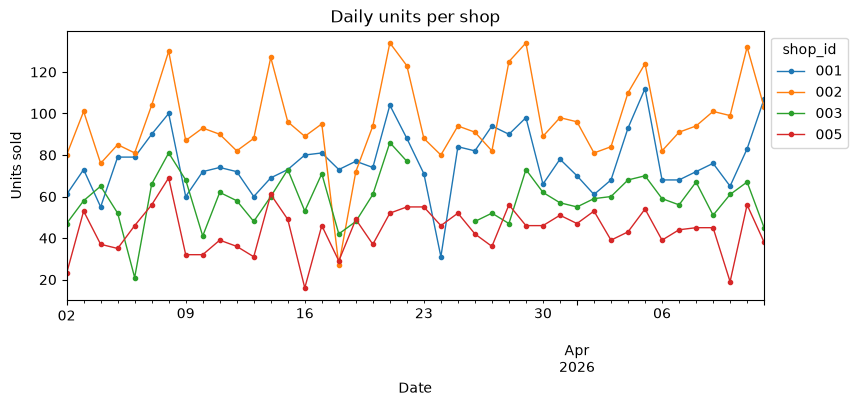

dates without any row for shop 003: 3


In [53]:
daily_by_shop = sales.pivot_table(index="date", columns="shop_id", values="units", aggfunc="sum")

fig, ax = plt.subplots(figsize=(9, 3.5))
daily_by_shop.plot(ax=ax, marker=".", linewidth=1)
ax.legend(title="shop_id", loc="upper left", bbox_to_anchor=(1.0, 1.0))
ax.set(xlabel="Date", ylabel="Units sold", title="Daily units per shop")
plt.show()

print("dates without any row for shop 003:", daily_by_shop["003"].isna().sum())

Paris is orange and gree; Lyon is blue.

**HW 5** *(after class if time is short)*. For each product, find the date with the highest total units over all shops. Hint: group by two keys and sum, then `unstack` and use `idxmax`. Store the result as a Series indexed by product. (Cake has a tie: two dates reach the same total, and either counts as correct.)

In [54]:
best_day = None   # replace None with your Series

accepted = {"cake": {"2026-03-14", "2026-03-28"}, "coffee": {"2026-03-08"}, "tea": {"2026-03-21"}}
if best_day is None:
    print("Not attempted yet.")
else:
    answer = {product: str(pd.Timestamp(day).date()) for product, day in best_day.items()}
    print("your answer:", answer)
    print("matches the target:", set(answer) == set(accepted)
          and all(answer[p] in accepted[p] for p in accepted))

Not attempted yet.


## 5. Putting it together
### 5.1 A weekly shop report (slides "Challenge: a weekly shop report" and "Challenge: checks and hints")

Start again from the file on disk. The six steps are on the slides. Each cell below checks your intermediate result against a target; **the solution is intentionally not included**. In step 2, correct the typing error by dividing the value by 10 (it is the true value typed with an extra 0).

In [55]:
products = pd.DataFrame({"product": ["coffee", "tea", "cake"],
                         "unit_price": [2.5, 2.0, 3.5]})
shops = pd.DataFrame({"shop_id": ["001", "002", "003", "004"],
                      "city": ["Lyon", "Paris", "Paris", "Lille"],
                      "region": ["South", "North", "North", "North"]})

TARGETS = {"max_units_after_fix": 78.0, "unmatched_rows": 125,
           "weekly_shape": (6, 3), "total_revenue": 24382.5}
print("Targets:", TARGETS)

# Steps 1-2: load and repair the file, then fix the typing error with ONE .loc assignment.
report_sales = None   # your DataFrame

if report_sales is None:
    print("Steps 1-2 not attempted yet.")
else:
    print("rows:", len(report_sales), "| max units:", report_sales["units"].max(),
          "| target:", TARGETS["max_units_after_fix"])
    fixed_cell = report_sales.loc[(report_sales["date"] == "2026-03-18")
                                  & (report_sales["shop_id"] == "002")
                                  & (report_sales["product"] == "coffee"), "units"]
    print("repaired value:", fixed_cell.tolist(), "| target: [58.0]")

Targets: {'max_units_after_fix': 78.0, 'unmatched_rows': 125, 'weekly_shape': (6, 3), 'total_revenue': 24382.5}
Steps 1-2 not attempted yet.


In [56]:
# Steps 3-4: merge products (validated) and compute revenue; merge shops with indicator=True,
# count the unmatched rows, and keep only the rows found in both tables.
known_sales = None    # your DataFrame
n_unmatched = None    # an integer

if known_sales is None or n_unmatched is None:
    print("Steps 3-4 not attempted yet.")
else:
    print("unmatched rows:", n_unmatched, "| target:", TARGETS["unmatched_rows"])
    print("revenue column present:", "revenue" in known_sales.columns)

Steps 3-4 not attempted yet.


In [57]:
# Step 5: a weeks x shops pivot table of total revenue, then each week's shares with NumPy.
# Hint: known_sales["date"].dt.to_period("W").dt.start_time gives the Monday of each week.
weekly = None    # your pivot table
shares = None    # your NumPy array

if weekly is None or shares is None:
    print("Step 5 not attempted yet.")
else:
    print("weekly shape:", weekly.shape, "| target:", TARGETS["weekly_shape"])
    print("total revenue:", round(float(np.nansum(weekly.to_numpy())), 2), "| target:", TARGETS["total_revenue"])
    print("each week's shares sum to 1:", np.allclose(np.asarray(shares).sum(axis=1), 1))

Step 5 not attempted yet.


lines drawn: 0 | expected: 3


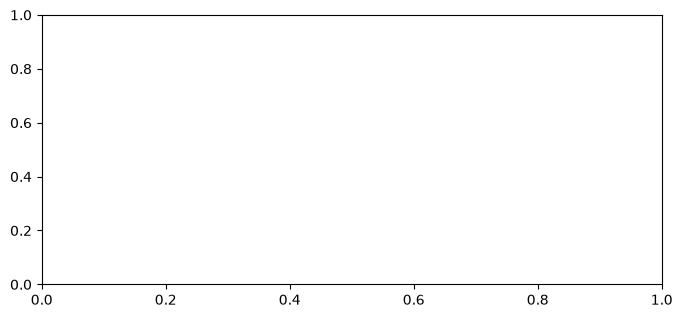

In [58]:
# Step 6: one figure, one line per shop, labelled axes and a legend.
fig, ax = plt.subplots(figsize=(8, 3.5))

# ... your plotting code here ...

print("lines drawn:", len(ax.lines), "| expected: 3")
plt.show()

### 5.2 Optional homework (slide "Homework (Optional but HIGHLY Recommended)")

Package your challenge steps into one documented function, as in Session 1. The stub below runs but does nothing yet: **the solution is intentionally not included**.

In [59]:
def weekly_report(path: Path) -> pd.DataFrame:
    """Build the weekly revenue table (weeks x known shops) from the raw sales file.

    Args:
        path (Path): location of session2_sales.csv.

    Returns:
        pd.DataFrame: total revenue per week (rows) and shop (columns).
    """
    pass  # TODO: reuse your challenge steps 1-5


print("weekly_report is intentionally unfinished:", weekly_report(DATA_PATH))

weekly_report is intentionally unfinished: None


## End of Session 2